<div style="width: 100%; clear: both;">
    <div style="float: left; width: 60%">
       <img src="https://www.fundacioudg.org/img/image/fotos/unigisnou2020.jpg?&w=270&h=144&zc=1&aoe=1&q=80", align="left">
    </div>
</div>

<div style="float: right; width: 40%;">
    <p style="margin: 0; padding-top: 22px; text-align:right;">Programación SIG con Python</p>
    <p style="margin: 0; text-align:right;">Máster Profesional en SIG</p>
    <p style="margin: 0; text-align:right;">2022/23</p>


</div>

</div>
<div style="width: 100%; clear: both;">
<div style="width:100%;">&nbsp;</div>

Análisis y visualización de datos para la observación de la Tierra
=======================================================================

PRÁCTICA 2 - Exploración y visualización de imágenes
------------------------------------------------------

En este Notebook encontraréis diferentes ejercicios relacionados con los diferentes procesos de exploración y visualización de imágenes de satélite. 

Los datos con los que deberéis trabajar son los que figuran en este enlace. Las imágenes corresponden a una muestra de una escena Landsat 8 (Collection 2 - Level 2)

Es muy importante que documentéis correctamente el código de los scripts, ya que además de valorar el resultado obtenido, se tendrá en consideración que entendáis el proceso. 
También es importante que el código esté bien estructurado.

Tened presente que deberéis realizar la instalación y la importación de las librerías oportunas. Podéis crear nuevas celdas si es necesario.
Las instrucciones **pip** para la instalación de las librerías debe realizarse en celdas independientes. 

Una vez resueltos los ejercicios y finalizada la actividad, deberéis entregar el archivo de Jupiter Notebook (ipynb). El nombre del archivo se referirá al número de la práctica, a los apellidos y al nombre. 
**No deberéis entregar el directorio de imágenes**. 





Ejercicio 1
-------------

Desarrolla un *script* en Python para visualizar el histograma de las bandas de la imágen correspondientes al canal Rojo, Verde, Azúl e Infrarrojo cercano. El número de clases debe ser de 80. 

Ayuda: Con la función *slice(start, end)* se pueden seleccionar los valores de un array, acorde a su posición dentro de este.  

**(1 punto)** 


In [1]:
!pip install numpy rasterio matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

In [3]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\Josemi\OneDrive\Documentos\Master\Año 2\4 Análisis y visualización de datos para la EO\P2
['.idea', '.venv', 'P2_Leon_Parra_MariaVictoria.ipynb', 'P2_Leon_Parra_MariaVictoria.zip', 'PRÁCTICA 2. Exploración y visualización de imágenes.pdf', 'sigte-datos_modulo_observaciontierra']


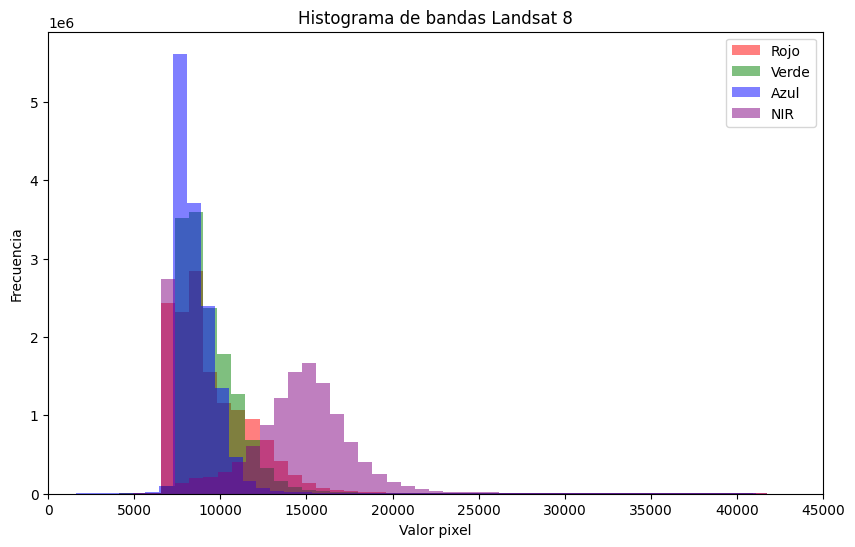

In [4]:
ruta = "sigte-datos_modulo_observaciontierra/Practica_2/"

# Leer bandas
banda_azul = rasterio.open(ruta + "LC09_L2SP_198031_20231105_20231106_02_T1_SR_B2.tif").read(1)
banda_verde = rasterio.open(ruta + "LC09_L2SP_198031_20231105_20231106_02_T1_SR_B3.tif").read(1)
banda_rojo = rasterio.open(ruta + "LC09_L2SP_198031_20231105_20231106_02_T1_SR_B4.tif").read(1)
banda_nir = rasterio.open(ruta + "LC09_L2SP_198031_20231105_20231106_02_T1_SR_B5.tif").read(1)

# Eliminar valores NoData (valores 0)
banda_azul = banda_azul[banda_azul > 0]
banda_verde = banda_verde[banda_verde > 0]
banda_rojo = banda_rojo[banda_rojo > 0]
banda_nir = banda_nir[banda_nir > 0]

# Crear figura
plt.figure(figsize=(10,6))

# Histogramas
plt.hist(banda_rojo.flatten(), bins=80, color="red", alpha=0.5, label="Rojo")
plt.hist(banda_verde.flatten(), bins=80, color="green", alpha=0.5, label="Verde")
plt.hist(banda_azul.flatten(), bins=80, color="blue", alpha=0.5, label="Azul")
plt.hist(banda_nir.flatten(), bins=80, color="purple", alpha=0.5, label="NIR")

plt.xlim(0, 45000)

# Detalles
plt.title("Histograma de bandas Landsat 8")
plt.xlabel("Valor pixel")
plt.ylabel("Frecuencia")
plt.legend()

plt.show()


Ejercicio 2
-------------

Desarrolla un *script* en Python para generar un diagrama de dispersión entre las bandas Roja e Infrarroja de la imágen. 

**(1 punto)** 


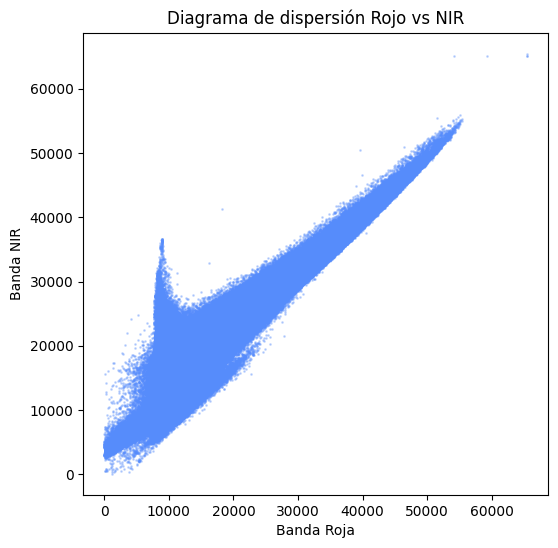

In [15]:
# Volver a leer las bandas completas
with rasterio.open(ruta + "LC09_L2SP_198031_20231105_20231106_02_T1_SR_B4.tif") as src:
    rojo = src.read(1)

with rasterio.open(ruta + "LC09_L2SP_198031_20231105_20231106_02_T1_SR_B5.tif") as src:
    nir = src.read(1)

# Crear una máscara común para eliminar NoData en ambas bandas
mascara = (rojo > 0) & (nir > 0)

rojo_valores = rojo[mascara]
nir_valores = nir[mascara]

# Diagrama de dispersión
plt.figure(figsize=(6, 6))
plt.scatter(rojo_valores, nir_valores, s=1, alpha=0.3)

plt.title("Diagrama de dispersión Rojo vs NIR")
plt.xlabel("Banda Roja")
plt.ylabel("Banda NIR")

plt.show()


Ejercicio 3
-------------

Desarrolla uns *script* en Python para aplicar una máscara sobre las nubes de la imagen Landsat.

**(3 puntos)** 


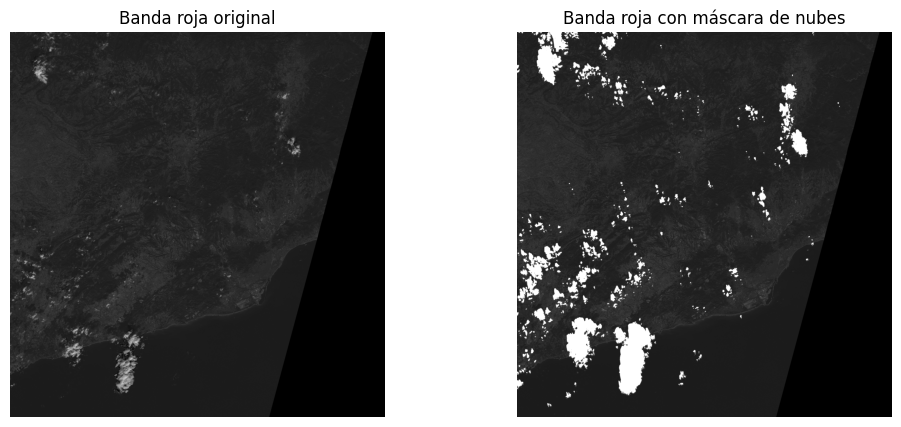

In [16]:
# Leer banda roja
with rasterio.open(ruta + "LC09_L2SP_198031_20231105_20231106_02_T1_SR_B4.tif") as src:
    rojo = src.read(1)

# Leer banda QA_PIXEL
with rasterio.open(ruta + "LC09_L2SP_198031_20231105_20231106_02_T1_QA_PIXEL.tif") as src:
    qa = src.read(1)

# Crear máscaras usando bits de QA_PIXEL
nube = (qa & (1 << 3)) > 0          # bit 3: nube
sombra_nube = (qa & (1 << 4)) > 0   # bit 4: sombra de nube
cirros = (qa & (1 << 2)) > 0        # bit 2: cirros

# Máscara final
mascara_nubes = nube | sombra_nube | cirros

# Aplicar máscara a la banda roja
rojo_sin_nubes = np.where(mascara_nubes, np.nan, rojo)

# Visualización comparativa
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(rojo, cmap="gray")
plt.title("Banda roja original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(rojo_sin_nubes, cmap="gray")
plt.title("Banda roja con máscara de nubes")
plt.axis("off")

plt.show()


Ejercicio 4
-------------

Desarrolla uns *script* en Python para visualizar una composición el color natural a partir de las bandas de la imagen Landsat. Aplicad las medidas pertinentes para conseguir una visualización lo más nítida posible. 

**(1 punto)** 


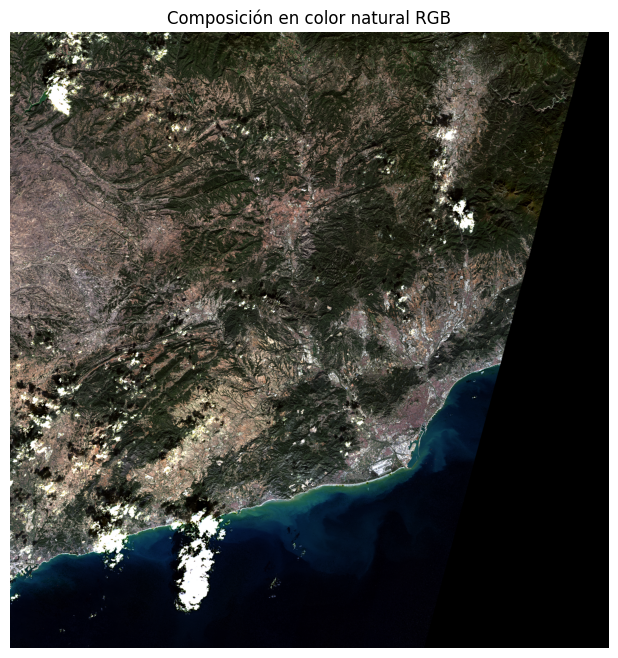

In [17]:
# Leer bandas RGB
with rasterio.open(ruta +"LC09_L2SP_198031_20231105_20231106_02_T1_SR_B4.tif") as src:
    rojo = src.read(1)

with rasterio.open(ruta +"LC09_L2SP_198031_20231105_20231106_02_T1_SR_B3.tif") as src:
    verde = src.read(1)

with rasterio.open(ruta +"LC09_L2SP_198031_20231105_20231106_02_T1_SR_B2.tif") as src:
    azul = src.read(1)

# Crear composición RGB
rgb = np.dstack((rojo, verde, azul))

# Función para mejorar contraste
def ajustar_contraste(imagen):
    p2, p98 = np.percentile(imagen[imagen > 0], (2, 98))
    imagen_ajustada = np.clip((imagen - p2) / (p98 - p2), 0, 1)
    return imagen_ajustada

# Aplicar contraste por banda
rgb_ajustada = np.dstack((
    ajustar_contraste(rojo),
    ajustar_contraste(verde),
    ajustar_contraste(azul)
))

# Visualizar
plt.figure(figsize=(8, 8))
plt.imshow(rgb_ajustada)
plt.title("Composición en color natural RGB")
plt.axis("off")
plt.show()

Ejercicio 5
-------------

Desarrolla un *script* en Python para visualizar, a partir de la imágen Landsat, una composición el en falso color de la **zona correspondiente al municipio de Barcelona**. 
Aplicad las medidas pertinentes para conseguir una visualización lo más nítida posible.
Entre los datos para resolver esta actividad, disponéis de un archivo shapefile con los límites del municipio de Barcelona. 

**(2 puntos)** 


In [11]:
!pip install geopandas

  Using cached geopandas-1.1.3-py3-none-any.whl.metadata (2.3 kB)
  Using cached pyogrio-0.12.1-cp312-cp312-win_amd64.whl.metadata (6.0 kB)
  Using cached pandas-3.0.2-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached pyproj-3.7.2-cp312-cp312-win_amd64.whl.metadata (31 kB)
  Using cached shapely-2.1.2-cp312-cp312-win_amd64.whl.metadata (7.1 kB)
Using cached geopandas-1.1.3-py3-none-any.whl (342 kB)
Using cached pandas-3.0.2-cp312-cp312-win_amd64.whl (9.7 MB)
Using cached pyogrio-0.12.1-cp312-cp312-win_amd64.whl (22.9 MB)
Using cached pyproj-3.7.2-cp312-cp312-win_amd64.whl (6.3 MB)
Using cached shapely-2.1.2-cp312-cp312-win_amd64.whl (1.7 MB)

   ---------------------------------------- 0/5 [shapely]
   ---------------------------------------- 0/5 [shapely]
   ---------------------------------------- 0/5 [shapely]
   ---------------------------------------- 0/5 [shapely]
   ---------------------------------------- 0/5 [shapely]
   ---------------------------------------- 0/5 [sh


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


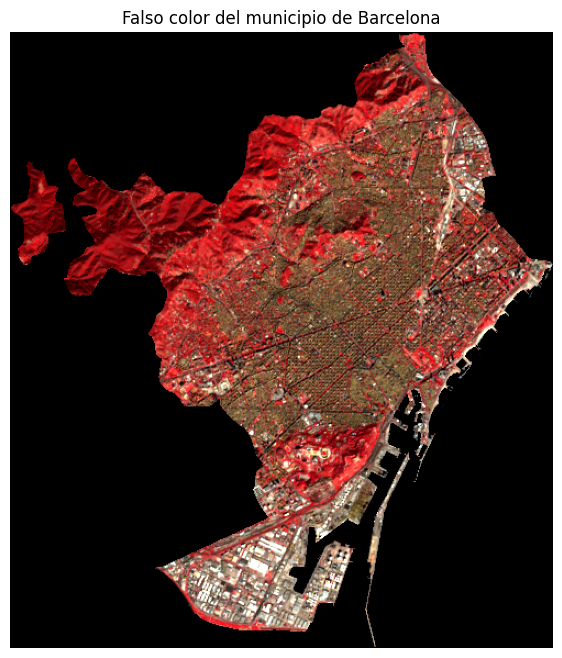

In [18]:
import geopandas as gpd
from rasterio.mask import mask

# Leer shapefile de Barcelona
bcn = gpd.read_file(ruta +"bcn.shp")

# Abrir una banda para obtener CRS
with rasterio.open(ruta +"LC09_L2SP_198031_20231105_20231106_02_T1_SR_B5.tif") as src:
    raster_crs = src.crs

# Reproyectar shapefile al CRS del raster
bcn = bcn.to_crs(raster_crs)

# Geometría del municipio
geometria = bcn.geometry

# Función para recortar una banda
def recortar_banda(ruta_banda, geometria):
    with rasterio.open(ruta_banda) as src:
        banda_recortada, transform = mask(src, geometria, crop=True)
    return banda_recortada[0]

# Recortar bandas para falso color
nir_bcn = recortar_banda(ruta +"LC09_L2SP_198031_20231105_20231106_02_T1_SR_B5.tif", geometria)
rojo_bcn = recortar_banda(ruta +"LC09_L2SP_198031_20231105_20231106_02_T1_SR_B4.tif", geometria)
verde_bcn = recortar_banda(ruta +"LC09_L2SP_198031_20231105_20231106_02_T1_SR_B3.tif", geometria)

# Crear composición falso color: NIR, Rojo, Verde
falso_color = np.dstack((nir_bcn, rojo_bcn, verde_bcn)).astype("float32")

# Eliminar valores NoData
falso_color[falso_color <= 0] = np.nan

# Ajuste de contraste global
p2, p98 = np.nanpercentile(falso_color, (2, 98))

falso_color_ajustada = (falso_color - p2) / (p98 - p2)
falso_color_ajustada = np.clip(falso_color_ajustada, 0, 1)
falso_color_ajustada = np.nan_to_num(falso_color_ajustada, nan=0)

# Visualizar
plt.figure(figsize=(8, 8))
plt.imshow(falso_color_ajustada)
plt.title("Falso color del municipio de Barcelona")
plt.axis("off")
plt.show()

Ejercicio 6
-------------

Desarrolla un *script* en Python para visualizar el índice NDVI y NDWI a partir de la imagen Landsat (con la máscara de nubes). Ambas representaciones deberán incorporar el título y la leyenda, así como una paleta de color adecuada.
Tened en consideración los factores de escalado de la imágen. 

**(2 puntos)** 


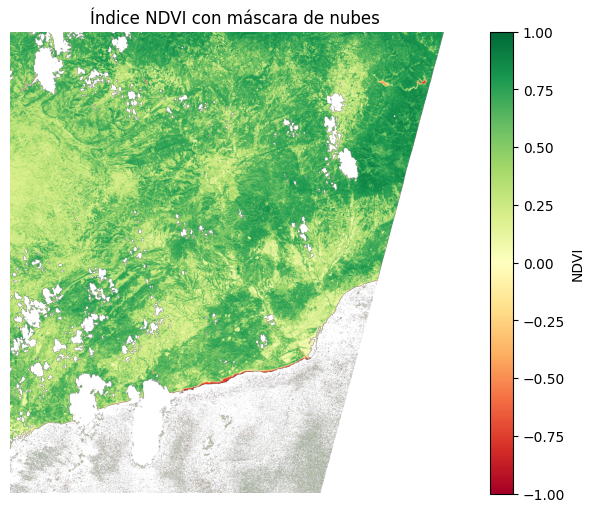

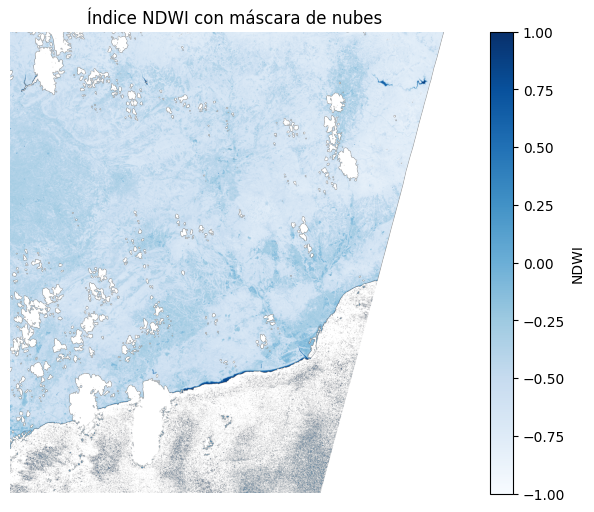

In [19]:
# Leer bandas necesarias
with rasterio.open(ruta +"LC09_L2SP_198031_20231105_20231106_02_T1_SR_B3.tif") as src:
    verde = src.read(1).astype("float32")

with rasterio.open(ruta +"LC09_L2SP_198031_20231105_20231106_02_T1_SR_B4.tif") as src:
    rojo = src.read(1).astype("float32")

with rasterio.open(ruta +"LC09_L2SP_198031_20231105_20231106_02_T1_SR_B5.tif") as src:
    nir = src.read(1).astype("float32")

with rasterio.open(ruta +"LC09_L2SP_198031_20231105_20231106_02_T1_QA_PIXEL.tif") as src:
    qa = src.read(1)

# Máscara de nubes, sombras y cirros
nube = (qa & (1 << 3)) > 0
sombra_nube = (qa & (1 << 4)) > 0
cirros = (qa & (1 << 2)) > 0

mascara_nubes = nube | sombra_nube | cirros

# Aplicar factores de escalado Landsat Collection 2 Level 2
verde = verde * 0.0000275 - 0.2
rojo = rojo * 0.0000275 - 0.2
nir = nir * 0.0000275 - 0.2

# Eliminar NoData y nubes
mascara_valida = (verde > 0) & (rojo > 0) & (nir > 0) & (~mascara_nubes)

# Crear arrays vacíos con NoData
ndvi = np.full(rojo.shape, np.nan, dtype="float32")
ndwi = np.full(rojo.shape, np.nan, dtype="float32")

# Calcular índices
ndvi[mascara_valida] = (nir[mascara_valida] - rojo[mascara_valida]) / (
    nir[mascara_valida] + rojo[mascara_valida]
)

ndwi[mascara_valida] = (verde[mascara_valida] - nir[mascara_valida]) / (
    verde[mascara_valida] + nir[mascara_valida]
)

# Visualizar NDVI
plt.figure(figsize=(8, 6))
img = plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.title("Índice NDVI con máscara de nubes")
plt.axis("off")
plt.colorbar(img, label="NDVI")
plt.show()

# Visualizar NDWI
plt.figure(figsize=(8, 6))
img = plt.imshow(ndwi, cmap="Blues", vmin=-1, vmax=1)
plt.title("Índice NDWI con máscara de nubes")
plt.axis("off")
plt.colorbar(img, label="NDWI")
plt.show()